# Monte Carlo decision agent: walkthrough

Four growth initiatives compete for the same budget: **improve the funnel**, run a **sales
webinar**, **double paid-ads spend** or **launch a new product**. This notebook walks through
how the project ranks them, and, because the data is synthetic, checks every estimate against
the ground truth that generated it.

1. Synthetic history with a known data-generating process
2. Models validated out of time
3. Counterfactual uplift **vs. the true causal effect** (and the bias of a naive model)
4. Paid-media saturation
5. Monte Carlo over model, demand and execution risk
6. The decision memo

Run it with `just setup --group notebook` and `just notebook`. Method details and limitations:
[`docs/methodology.md`](../docs/methodology.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from montecarlo_decisions.agent.memo import rule_based_memo
from montecarlo_decisions.agent.tools import Toolbox
from montecarlo_decisions.artifacts import load_artifacts
from montecarlo_decisions.config import artifact_paths
from montecarlo_decisions.pipeline import prepare_case, run_simulation

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
FIGURES = ROOT / "docs" / "img"
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Reference categorical palette (fixed order = fixed identity), ink and surface tokens.
DECISION_COLORS = {
    "funnel": "#2a78d6",
    "webinar": "#eb6834",
    "ads": "#1baf7a",
    "new_product": "#eda100",
}
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.8,
        "font.size": 10,
        "axes.titleweight": "bold",
        "axes.titlesize": 12,
        "axes.axisbelow": True,
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
    }
)

In [2]:
paths = artifact_paths(ROOT / "artifacts")
prepared = prepare_case()  # data + models + bootstrap refits (~15 s)
result = run_simulation(prepared, paths, n_simulations=10_000)
artifacts = load_artifacts(paths)
labels = prepared.config.labels()
for check in result.checks:
    print(("PASS " if check.passed else "FAIL ") + check.name)

PASS data_integrity
PASS conversion_model_discrimination
PASS conversion_model_calibration
PASS counterfactual_recovery
PASS ranking_resolved


## 1. The history

20,000 commercial opportunities (Jan 2024 to Apr 2026). Each row carries its acquisition
context, the marketing levers active at the time and the economic outcome. The levers were
rolled out **over time**, and baseline conversion also drifts upwards month after month: that
overlap is what makes naive estimates biased (section 3).

In [3]:
history = prepared.history
(
    history.groupby("channel")
    .agg(
        opportunities=("transaction_id", "count"),
        conversion=("converted_to_sale", "mean"),
        contribution_eur=("contribution_profit_eur", "sum"),
        cost_per_opportunity=("cost_attributed_eur", "mean"),
    )
    .sort_values("contribution_eur", ascending=False)
)

,opportunities,conversion,contribution_eur,cost_per_opportunity
channel,,,,
Email,3390,0.17,"491,017.53",0.72
Webinar,1581,0.20,"292,147.84",5.62
SEO / Blog,3008,0.11,"275,203.48",1.84
YouTube Organico,2376,0.11,"201,846.09",1.24
Google Ads,3147,0.07,"110,523.73",13.39
Afiliados,1774,0.08,"74,913.85",7.20
Facebook Ads,4724,0.05,"69,310.08",15.99


## 2. Models, validated out of time

`P(sale)` (logistic regression) x `E[ticket | sale]` (gradient boosting on log-ticket with Duan
smearing) x `E[margin]` - acquisition cost - support cost = **expected value per opportunity**.
The models are trained on the oldest 80% of opportunities and scored on the most recent 20%.

In [4]:
report = prepared.model_report
split = report["split"]
pd.Series(
    {
        "test period": f"{split['test_period_start']} to {split['test_period_end']}",
        "AUC (out of time)": round(report["classification"]["auc"], 3),
        "Brier score": round(report["classification"]["brier"], 4),
        "Expected calibration error": round(
            report["classification"]["expected_calibration_error"], 4
        ),
        "Ticket MAE (EUR)": round(report["regression"]["mae_eur"], 1),
        "Ticket R2": round(report["regression"]["r2"], 3),
    }
).to_frame("value")

,value
test period,2025-12-17 to 2026-04-30
AUC (out of time),0.71
Brier score,0.11
Expected calibration error,0.01
Ticket MAE (EUR),227.30
Ticket R2,0.79


## 3. Counterfactual uplift vs. the truth

For each lever the same opportunities are copied, the treatment is forced and the models
re-predict. Because the data is synthetic, the *true* effect can be computed from the
data-generating process and compared with:

- **model**: time-controlled models, with a 95% interval from 20 bootstrap refits;
- **naive**: the same models without a calendar control (the specification of the original
  project).

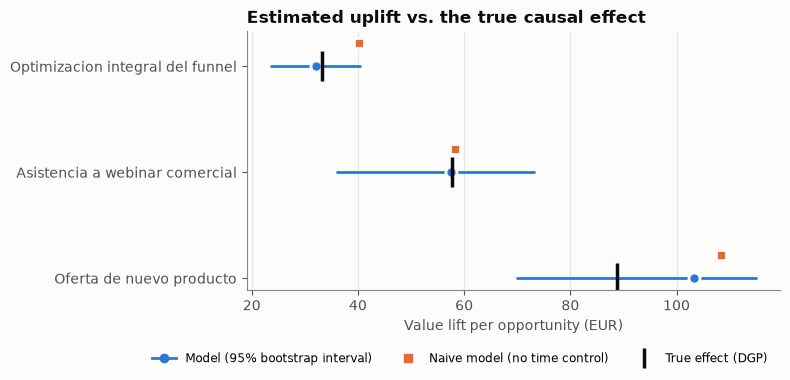

,value_lift_per_opportunity_eur,true_value_lift_per_opportunity_eur,naive_value_lift_per_opportunity_eur,value_lift_error_pct,naive_value_lift_error_pct,truth_in_interval
lever,,,,,,
funnel,32.13,33.30,40.12,-0.04,0.20,True
webinar,57.53,57.74,58.21,-0.00,0.01,True
new_product,103.37,88.71,108.42,0.17,0.22,True


In [5]:
uplift = prepared.uplift.set_index("lever")
fig, ax = plt.subplots(figsize=(8, 4))
rows = list(uplift.index)[::-1]
for y, lever in enumerate(rows):
    row = uplift.loc[lever]
    ax.plot(
        [row.value_lift_ci_low_eur, row.value_lift_ci_high_eur],
        [y, y],
        color="#2a78d6",
        lw=2,
        solid_capstyle="round",
    )
    ax.plot(row.value_lift_per_opportunity_eur, y, "o", ms=8, color="#2a78d6", mec=SURFACE, mew=2)
    ax.plot(
        row.naive_value_lift_per_opportunity_eur,
        y + 0.22,
        "s",
        ms=7,
        color="#eb6834",
        mec=SURFACE,
        mew=2,
    )
    ax.plot(row.true_value_lift_per_opportunity_eur, y, "|", ms=22, mew=2.5, color=INK)
ax.set_yticks(range(len(rows)), [uplift.loc[lever, "label"] for lever in rows])
ax.set_xlabel("Value lift per opportunity (EUR)")
ax.set_title("Estimated uplift vs. the true causal effect")
handles = [
    plt.Line2D([], [], color="#2a78d6", marker="o", lw=2, label="Model (95% bootstrap interval)"),
    plt.Line2D([], [], color="#eb6834", marker="s", lw=0, label="Naive model (no time control)"),
    plt.Line2D([], [], color=INK, marker="|", ms=14, mew=2.5, lw=0, label="True effect (DGP)"),
]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.4, -0.2),
    ncol=3,
    frameon=False,
    fontsize=8.5,
)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "counterfactual_recovery.png", dpi=160)
plt.show()

uplift[
    [
        "value_lift_per_opportunity_eur",
        "true_value_lift_per_opportunity_eur",
        "naive_value_lift_per_opportunity_eur",
        "value_lift_error_pct",
        "naive_value_lift_error_pct",
        "truth_in_interval",
    ]
]

**Reading.** Without the calendar control, the funnel uplift is overstated by about 20%: part of
the upward drift in conversion is credited to the funnel changes that happened to roll out at the
same time. With the control the error drops to a few percent and every true effect lies inside
its bootstrap interval. The new-product lever is the least precise (only ~550 historical offers,
all in the last seven months); its interval is correspondingly wide.

## 4. Paid media is already saturated

The "double ad spend" decision moves every paid opportunity one budget level up. How lead score
and cost respond is **estimated from the history**, not assumed:

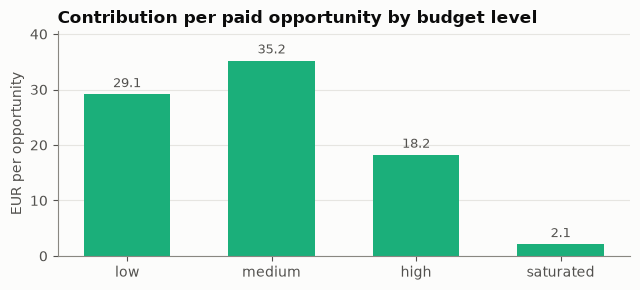

,opportunities,conversion_rate,mean_lead_score,mean_cost_eur
ad_budget_level,,,,
low,786,0.06,54.66,10.60
medium,3319,0.07,52.37,12.05
high,1996,0.05,46.54,15.42
saturated,1770,0.03,36.93,21.79


In [6]:
regimes = artifacts.ads_regimes.set_index("ad_budget_level")
fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.bar(
    regimes.index, regimes["contribution_per_opportunity_eur"], color="#1baf7a", width=0.6
)
ax.bar_label(bars, fmt="%.1f", color=INK_2, padding=3, fontsize=9)
ax.margins(y=0.15)
ax.set_ylabel("EUR per opportunity")
ax.set_title("Contribution per paid opportunity by budget level")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "ads_saturation.png", dpi=160)
plt.show()
regimes[["opportunities", "conversion_rate", "mean_lead_score", "mean_cost_eur"]]

In the recent window most paid traffic is already at *high* or *saturated* budget levels, where
each extra step lowers lead quality and raises cost. Doubling spend therefore destroys value on
the existing paid opportunities faster than the extra volume adds it.

## 5. Monte Carlo

Each of the 10,000 futures draws a bootstrap model refit, a resample of today's opportunity mix
and a demand shock (shared by all decisions: common random numbers), plus independent execution
risk per decision (failure, partial realisation, cost overrun; see `scenarios.toml`).

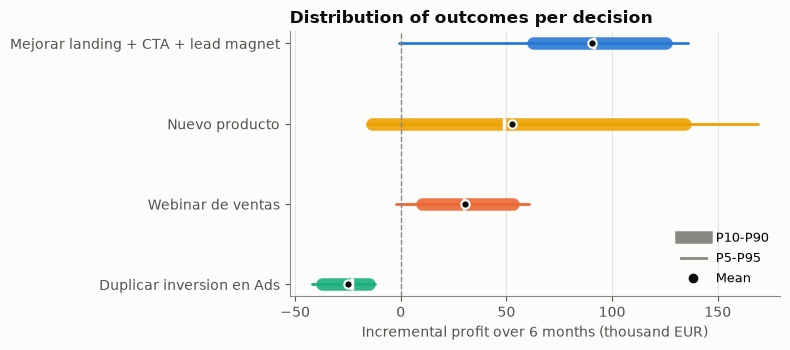

,expected_profit_eur,p10_eur,p90_eur,cvar_5_eur,probability_loss,probability_best,expected_roi,breakeven_failure_probability
label,,,,,,,,
Mejorar landing + CTA + lead magnet,"90,330.11","62,384.08","125,409.78","-1,206.04",0.05,0.71,75.20,0.99
Nuevo producto,"52,873.48","-13,620.23","134,457.97","-18,593.00",0.36,0.26,4.41,0.88
Webinar de ventas,"30,602.14","9,969.62","52,908.65","-2,772.13",0.09,0.03,12.24,0.93
Duplicar inversion en Ads,"-24,878.09","-37,188.48","-15,022.04","-48,981.11",1.00,0.00,-2.77,0.00


In [7]:
sims = artifacts.simulations
order = artifacts.summary.sort_values("ranking")["decision"].tolist()
fig, ax = plt.subplots(figsize=(8, 3.6))
for y, key in enumerate(order[::-1]):
    profit = sims.loc[sims["decision"] == key, "incremental_profit_eur"] / 1000
    p5, p10, p50, p90, p95 = np.percentile(profit, [5, 10, 50, 90, 95])
    color = DECISION_COLORS[key]
    ax.plot([p5, p95], [y, y], color=color, lw=2, solid_capstyle="round")
    ax.plot([p10, p90], [y, y], color=color, lw=9, solid_capstyle="round", alpha=0.9)
    ax.plot(p50, y, "|", color=SURFACE, ms=9, mew=2.5)
    ax.plot(profit.mean(), y, "o", color=INK, ms=6, mec=SURFACE, mew=1.5)
ax.axvline(0, color=MUTED, lw=1, ls="--")
ax.set_yticks(range(len(order)), [labels[key] for key in order[::-1]])
ax.set_xlabel("Incremental profit over 6 months (thousand EUR)")
ax.set_title("Distribution of outcomes per decision")
ax.legend(
    handles=[
        plt.Line2D([], [], color=MUTED, lw=9, label="P10-P90"),
        plt.Line2D([], [], color=MUTED, lw=2, label="P5-P95"),
        plt.Line2D([], [], color=INK, marker="o", lw=0, label="Mean"),
    ],
    loc="lower right",
    frameon=False,
    fontsize=9,
)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "decision_distributions.png", dpi=160)
plt.show()

artifacts.summary.set_index("label")[
    [
        "expected_profit_eur",
        "p10_eur",
        "p90_eur",
        "cvar_5_eur",
        "probability_loss",
        "probability_best",
        "expected_roi",
        "breakeven_failure_probability",
    ]
]

**Reading.** The funnel wins in expectation and in the tails: it is the best option in roughly
seven out of ten futures and would stay profitable unless its failure probability were close to
certainty. The new product has the highest upside (P90) but a one-in-three chance of losing money.
Doubling ads loses money in essentially every future. `breakeven_failure_probability` says how
wrong the execution-risk assumption would have to be before a decision stops paying off.

## 6. The decision memo

The agent reads the same tools a human analyst would (the ground truth is *not* exposed to it)
and writes the memo shown in the dashboard. Without an API key the project falls back to a
deterministic, rule-based memo, clearly labelled as such. With `ANTHROPIC_API_KEY` set, `just memo`
has Claude write it through a tool-use loop.

In [8]:
memo = rule_based_memo(Toolbox(artifacts))
print(memo["headline"], "\n")
print(memo["summary"], "\n")
for item in memo["watchouts"]:
    print("-", item)

Priorizar Mejorar landing + CTA + lead magnet: mayor beneficio esperado con el riesgo acotado. 

Mejorar landing + CTA + lead magnet genera 90.330 EUR esperados en el horizonte, con P(perdida) de 5.1% y es la mejor opcion en el 71% de los futuros simulados. Nuevo producto queda segunda a 37.457 EUR de distancia. 

- Duplicar inversion en Ads es la opcion con mas riesgo: 100.0% de probabilidad de perder dinero y CVaR 5% de -48.981 EUR.
- Nuevo producto tiene la mayor dispersion (P10 -13.620 EUR, P90 134.458 EUR): su resultado depende mas de la ejecucion que del modelo.
- Beneficio esperado negativo en: Duplicar inversion en Ads. No deberian financiarse tal cual.
